# N-real · 真实困惑度 (gpt2): 最朴素的内在评估

> **小而真** (配套 eval-foundations) · 困惑度 (perplexity) = 模型对一段文本「有多意外」, 是最经典的内在评估。
> 这里用**真实 gpt2** 算困惑度, 看它怎么区分通顺/打乱/重复/异常文本。CPU 离线确定性。

In [1]:
import sys, time
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parents[1] / "_shared"))
import realmodels as rm
import numpy as np, torch
print("真实模型可用性:", rm.available())

C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


真实模型可用性: {'gpt2': True, 'TinyLlama/TinyLlama-1.1B-Chat-v1.0': True}


> 若上面显示某模型为 False, 表示本机无该 HF 缓存, 真实例子会自动跳过 (不影响本专题的 toy notebook)。

## 1. 困惑度区分文本质量 (真实 gpt2)

In [2]:
tok, model = rm.gpt2()
samples = {
    "通顺英文":   "The sun rose over the quiet mountain village.",
    "打乱词序":   "village mountain quiet the over rose sun The.",
    "无意义重复": "the the the the the the the the the the.",
    "随机字符":   "xq7 zk! pm9 vbn? wgt zz qj4 lll.",
    "另一通顺句": "She opened the book and began to read slowly.",
}
if model is not None:
    print(f"{'文本类型':10} {'困惑度':>10}   (越低 = 模型越觉得自然)")
    ppl = {}
    for name, text in samples.items():
        ppl[name] = rm.perplexity(tok, model, text)
        print(f"{name:10} {ppl[name]:10.1f}   {text}")
else:
    print("无 gpt2, 跳过"); ppl = {}

文本类型              困惑度   (越低 = 模型越觉得自然)


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


通顺英文             92.7   The sun rose over the quiet mountain village.
打乱词序           8098.9   village mountain quiet the over rose sun The.
无意义重复            16.0   the the the the the the the the the the.
随机字符            452.0   xq7 zk! pm9 vbn? wgt zz qj4 lll.
另一通顺句            21.5   She opened the book and began to read slowly.


## 2. 可视化: 困惑度排序就是「自然度」排序

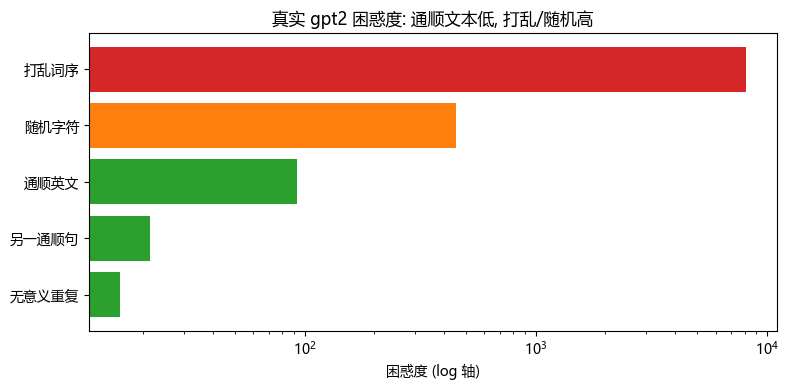

→ 困惑度自动把文本按「模型眼中的自然度」排序, 无需标注。这是最便宜的内在评估。


In [3]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
if ppl:
    names = list(ppl.keys()); vals = [ppl[n] for n in names]
    order = np.argsort(vals)
    names = [names[i] for i in order]; vals = [vals[i] for i in order]
    plt.figure(figsize=(8,4))
    plt.barh(names, vals, color=['C2' if v<200 else 'C1' if v<2000 else 'C3' for v in vals])
    plt.xscale('log'); plt.xlabel('困惑度 (log 轴)')
    plt.title('真实 gpt2 困惑度: 通顺文本低, 打乱/随机高')
    plt.tight_layout(); plt.show()
    print("→ 困惑度自动把文本按「模型眼中的自然度」排序, 无需标注。这是最便宜的内在评估。")

## 3. 反思 (困惑度的用途与陷阱)
- **用途**: 预训练监控 (loss=交叉熵, ppl=exp(loss))、数据质量筛 (高 ppl 可能是脏数据)、模型比较。
- **陷阱**: 困惑度低 ≠ 有用/正确/安全。它只衡量「像不像训练分布」, 不衡量任务表现。
- 所以它是**内在评估**; 真要评能力还得**外在评估** (下游任务、人评、judge —— 本模块后续 + judge 模块)。

> 你在真模型上看到了困惑度的判别力, 也看到了它的边界: 评估永远是「测的是不是你真关心的东西」。